In [2]:
import pandas as pd 


# Ratings 


ratings = pd.read_csv("C:/Users/oscwa/recommendation_system/data/ratings.csv", index_col = 0)


# Get number of ratings per user 

ratings.groupby("userid")["rating"].count().sort_values(ascending= False)

# Get average rating per user 

ratings.groupby("userid")["rating"].mean().sort_values(ascending= False)


# get time period of ratings 

ratings["date"] = pd.to_datetime(ratings["timestamp"], unit = "s")
ratings["year"] = ratings["date"].dt.year


ratings.groupby("year")["rating"].count().sort_values(ascending= False)


ratings.groupby(["userid", "rating"]).count()


movieid  timestamp  date  year
userid rating                                
1      3             8          8     8     8
       4            27         27    27    27
       5            18         18    18    18
2      1             2          2     2     2
       2            11         11    11    11
...                ...        ...   ...   ...
6040   1            27         27    27    27
       2            38         38    38    38
       3            63         63    63    63
       4           137        137   137   137
       5            76         76    76    76

[28370 rows x 4 columns]

In [3]:
# items 

items = pd.read_csv("C:/Users/oscwa/recommendation_system/data/movies.csv", index_col = 0)


print(items)

      MovieID                               Title  \
0           1                    Toy Story (1995)   
1           2                      Jumanji (1995)   
2           3             Grumpier Old Men (1995)   
3           4            Waiting to Exhale (1995)   
4           5  Father of the Bride Part II (1995)   
...       ...                                 ...   
3878     3948             Meet the Parents (2000)   
3879     3949          Requiem for a Dream (2000)   
3880     3950                    Tigerland (2000)   
3881     3951             Two Family House (2000)   
3882     3952               Contender, The (2000)   

                            Genres  
0      Animation|Children's|Comedy  
1     Adventure|Children's|Fantasy  
2                   Comedy|Romance  
3                     Comedy|Drama  
4                           Comedy  
...                            ...  
3878                        Comedy  
3879                         Drama  
3880                         D

In [4]:
import torch

users = pd.read_csv("C:/Users/oscwa/recommendation_system/data/users.csv", index_col = 0)


users["Gender"] = [1 if i == "M" else 0 for i in users["Gender"]]

print(users)



useridx = {uid: i for i, uid in enumerate(users["UserID"].unique())}

indices = list(range(1,len(useridx)))

embedding_table = torch.nn.Embedding(len(users), 64)

batch_idx = torch.tensor([useridx[u] for u in indices])


embedding_table.weight[torch.tensor(1)]

      UserID  Gender  Age  Occupation Zip-code
0          1       0    1          10    48067
1          2       1   56          16    70072
2          3       1   25          15    55117
3          4       1   45           7    02460
4          5       1   25          20    55455
...      ...     ...  ...         ...      ...
6035    6036       0   25          15    32603
6036    6037       0   45           1    76006
6037    6038       0   56           1    14706
6038    6039       0   45           0    01060
6039    6040       1   25           6    11106

[6040 rows x 5 columns]


tensor([ 0.0739,  3.0331, -0.0300,  0.2030,  0.7843,  0.8098,  0.5454, -0.7063,
        -0.9872,  1.8868,  0.0821,  1.6349, -0.1249,  0.3659,  0.2277, -0.9087,
        -2.0213,  2.4991, -1.1795,  0.0608,  0.6274,  0.6602,  0.3430, -0.5493,
        -1.1399,  0.3464, -0.7592,  1.4025,  0.8946,  0.1396, -0.7477, -0.2732,
        -1.2926, -0.9604,  0.7196, -2.0765,  0.6842, -0.0617, -0.1785, -1.7536,
         0.8167,  1.5581, -0.7385,  0.5413, -1.0047,  1.9041,  0.0864, -1.1696,
         0.2104,  1.2091,  0.3888, -1.0260,  0.6353,  1.0508,  0.4053,  0.0185,
         0.5842,  0.9386, -0.1139, -0.4048,  0.8355,  1.2917,  0.9571,  1.2919],
       grad_fn=<SelectBackward0>)

In [5]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset, DataLoader
import torch 
from collections import defaultdict
import numpy as np 

ratings["label"] = [1 if i > 2 else 0 for i in ratings["rating"]]

# keep only users with ≥ 1 positive rating
pos_counts = ratings.groupby("userid")["label"].sum()
good_users = pos_counts[pos_counts > 0].index

# (optional) keep only items with ≥ 1 positive rating
item_counts = ratings.groupby("movieid")["label"].sum()
good_items = item_counts[item_counts > 0].index

# filter df
ratings_filtered = ratings[
    ratings["userid"].isin(good_users) &
    ratings["movieid"].isin(good_items)
]

ratings_filtered["user_idx"] = ratings_filtered["userid"].astype("category").cat.codes
ratings_filtered["item_idx"] = ratings_filtered["movieid"].astype("category").cat.codes

#user_cat = ratings_filtered["userid"].astype("category")
#item_cat = ratings_filtered["movieid"].astype("category")

class userdataset(Dataset):
    def __init__(self, data, strong_neg_weight, weak_neg_weight, k):
        self.data = data
        self.users = self.data["user_idx"].unique()
        self.items = self.data["item_idx"].unique()
        self.positive_by_user, self.negative_by_user = self.create_lookup()
        self.strong_neg_weight = strong_neg_weight
        self.weak_neg_weight = weak_neg_weight
        self.k = k


    def sample_strong_negatives(self, user_id):
         if self.negative_by_user[user_id]:
           item = np.random.choice(list(self.negative_by_user[user_id]))
           return item, self.strong_neg_weight
         else:
          
           return self.sample_weak_negatives(user_id)
         
    def sample_weak_negatives(self,user_id):      
         while True:
           item = np.random.choice(self.items)           
           
           if (item not in self.positive_by_user[user_id]) and (item not in  self.negative_by_user[user_id]):

                return int(item), self.weak_neg_weight
             
         
    
    def sample_positive(self, user_id):
           return np.random.choice(list(self.positive_by_user[user_id]))

           
         
    def create_lookup(self):
        
          users_positive_pairs = defaultdict(set) 
          users_negative_pairs = defaultdict(set)
        
          for row in self.data.itertuples(index= False):
            if row.rating > 2:
                users_positive_pairs[row.user_idx].add(row.item_idx)
            else:
                users_negative_pairs[row.user_idx].add(row.item_idx)

          return users_positive_pairs, users_negative_pairs
          
    def get_k_negatives(self, user_id):
      
        negs = []
        weights = []

        strong_neg, strong_weight = self.sample_strong_negatives(user_id)
 
        

        for i in range(self.k):
            weak_neg, weak_weight = self.sample_weak_negatives(user_id)
            negs.append(weak_neg)
            weights.append(weak_weight)
        negs.append(strong_neg)
        weights.append(strong_weight)
        return negs, weights 
            
    def __len__(self):
        return len(self.users)                       
        
          
    def __getitem__(self, user_id):
        pos = self.sample_positive(user_id)
        negs, weights = self.get_k_negatives(user_id)

        return (torch.tensor(user_id),
                torch.tensor(pos), 
                torch.tensor(negs, dtype= torch.long), 
                torch.tensor(weights, dtype = torch.long)
                )
    


        
        
     


C:\Users\oscwa\AppData\Local\Temp\ipykernel_43192\1675203991.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_filtered["user_idx"] = ratings_filtered["userid"].astype("category").cat.codes
C:\Users\oscwa\AppData\Local\Temp\ipykernel_43192\1675203991.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_filtered["item_idx"] = ratings_filtered["movieid"].astype("category").cat.codes


In [21]:
dataset = userdataset(ratings_filtered, strong_neg_weight=1, weak_neg_weight= 0.25, k = 2)



dataloader_train = DataLoader(dataset, batch_size=32, shuffle=True, drop_last= True)

#u, pos, negs, weights = next(iter(dataloader_train))


#for u, pos, negs, weights in dataloader_train:
#        print(u, pos, negs, weights)
#        embedding_table.weight[pos]
        




#print(u, pos, negs, weights)








In [32]:
#len(set(pos_pairs[pos_pairs["rating"] > 2]["userid"]))
#len(set(pos_pairs["userid"]))

#for i in range(1000):
# dataset.sample_strong_negatives(1089)
import torch 
import torch.nn as nn


class TwoTowerModel(nn.Module):
    def __init__(self, user_dim, item_dim, embedd_dim):
        super(TwoTowerModel, self).__init__()

        self.user_dim = user_dim
        self.item_dim = item_dim
        self.embedd_dim = embedd_dim

        self.item_embedding = nn.Embedding(self.item_dim, self.embedd_dim)
        self.user_embedding = nn.Embedding(self.user_dim, self.embedd_dim)

        
    
    def forward(self, users, pos, neg):
        s_negative_embedding = self.item_embedding(neg)
        s_pos_embedding = self.item_embedding(pos)
        user_embedding = self.user_embedding(users)
        return s_negative_embedding, s_pos_embedding, user_embedding

In [33]:


item_dim = len(set(ratings_filtered["item_idx"]))
user_dim = len(set(ratings_filtered["user_idx"]))


model = TwoTowerModel(user_dim= user_dim, item_dim= item_dim, embedd_dim= 512)

In [ ]:

import torch.optim as optim

class BPRLoss(nn.Module):
    def forward(self, user, neg, pos, weights, criterion):
            cosine_vector_neg = criterion(user.unsqueeze(1), neg)
            cosine_vector_pos = criterion(user, pos).unsqueeze(1)

            return ((-(torch.log(torch.sigmoid(cosine_vector_pos - cosine_vector_neg))))*weights).mean()
        
 


class train:
       def __init__(self, model, data, num_epochs, lr):

        self.num_epochs = num_epochs 
        self.lr = lr 
        self.model = model
        self.data = data 
        

       def train(self):

        optimizer = optim.Adam(self.model.parameters(), lr= self.lr)
        score = torch.nn.CosineSimilarity(dim = -1)
        loss_fn = BPRLoss()
        train_loss = []
        for epoch in range(self.num_epochs):
                running, nsteps = 0.0, 0
                for u, pos, negs, weights in self.dataloader:
                        optimizer.zero_grad()
                        neg, pos, user = model(u, pos, negs)

                        weight_vector = weights


                
                        loss = loss_fn(user, neg, pos, weight_vector, score)
                        loss.backward()
                        optimizer.step()
        
                        running += loss.item()
                        nsteps += 1
                total_loss = running / max(nsteps,1)
                train_loss.append(total_loss)
                print(f"epoch [{epoch+1}/{self.num_epochs}], loss: {total_loss:.6f}")

        

        #cosine_vector_neg = score(user.unsqueeze(1), neg)

        #cosine_vector_pos = score(user, pos).unsqueeze(1)

  
        #loss = (-(torch.log(torch.sigmoid(cosine_vector_pos - cosine_vector_neg))) * weight_vector).mean()
        #print(loss)
        








epoch [1/100], loss: 0.221241
epoch [2/100], loss: 0.218682
epoch [3/100], loss: 0.216002
epoch [4/100], loss: 0.213482
epoch [5/100], loss: 0.210625
epoch [6/100], loss: 0.207741
epoch [7/100], loss: 0.205669
epoch [8/100], loss: 0.203021
epoch [9/100], loss: 0.201648
epoch [10/100], loss: 0.199152
epoch [11/100], loss: 0.197541
epoch [12/100], loss: 0.195714
epoch [13/100], loss: 0.194364
epoch [14/100], loss: 0.192736
epoch [15/100], loss: 0.191132
epoch [16/100], loss: 0.189955
epoch [17/100], loss: 0.188704
epoch [18/100], loss: 0.187155
epoch [19/100], loss: 0.186316
epoch [20/100], loss: 0.185460
epoch [21/100], loss: 0.183942
epoch [22/100], loss: 0.183476
epoch [23/100], loss: 0.182236
epoch [24/100], loss: 0.181195
epoch [25/100], loss: 0.180046
epoch [26/100], loss: 0.179391
epoch [27/100], loss: 0.178503
epoch [28/100], loss: 0.177521
epoch [29/100], loss: 0.176898
epoch [30/100], loss: 0.175997
epoch [31/100], loss: 0.174981
epoch [32/100], loss: 0.174421
epoch [33/100], l

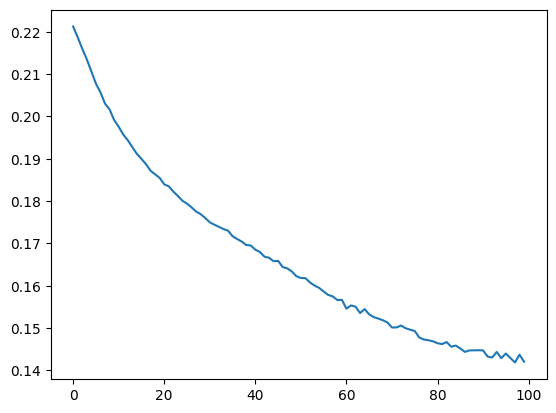

In [35]:
import matplotlib.pyplot as plt 


plt.plot(train_loss)